<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Semana%2011-RegresionCategoricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programación para Analítica Descriptiva y Predictiva

- Maestría en Inteligencia Artificial y Analítica de Datos
- Modelos de Regresión con Datos Categóricos Nominales

# Regresión Lineal Simple y Múltiple con Datos Categóricos

Los modelos de regresión con variables categóricas representan una herramienta fundamental para el análisis estadístico avanzado en ciencia de datos. Estas técnicas permiten transformar datos cualitativos en componentes esenciales de modelos predictivos robustos, ampliando las posibilidades analíticas más allá de las variables puramente numéricas.

Durante este curso exploraremos metodologías especializadas para incorporar variables categóricas en modelos predictivos, con especial énfasis en la implementación mediante Scikit-Learn, la biblioteca de aprendizaje automático más utilizada en Python. Examinaremos desde los fundamentos teóricos hasta aplicaciones prácticas en diversos contextos profesionales.

## Fundamentos de Variables Categóricas

**Variables Nominales**

- Representan categorías sin orden intrínseco. Ejemplos incluyen género, país de origen, o tipo de producto. No existe una relación ordinal entre sus valores, lo que presenta desafíos particulares para su incorporación en modelos predictivos.

**Variables Ordinales**

- Poseen un orden natural entre categorías. Ejemplos como nivel educativo, satisfacción del cliente o severidad de una enfermedad. Su naturaleza ordinal ofrece información adicional que puede aprovecharse en el modelado estadístico.

**Desafíos Analíticos**

- Las variables categóricas no pueden utilizarse directamente en modelos matemáticos que requieren entradas numéricas. Su transformación adecuada resulta crucial para preservar la información mientras se adaptan a los requisitos algorítmicos.

La correcta identificación y tratamiento de estos tipos de variables resulta fundamental para evitar sesgos y obtener modelos estadísticamente válidos. La interpretabilidad de los resultados depende significativamente de las decisiones tomadas durante esta fase inicial del análisis.


## Métodos de Codificación

One-Hot Encoding

Crea columnas binarias (dummy) para cada categoría. Preserva la naturaleza nominal sin imponer relaciones ordinales. Puede generar matrices dispersas con alta dimensionalidad cuando existen muchas categorías.

Existen dos versiones en la literatura en la forma en la que se crean variables dummy de acuerdo al número de categorías presente en la variable. Sea K = número de categorías, entonces

1. Se crean K nuevos atributos/columnas
2. Se crean K-1 nuevos atributos/columnas

En cada columna se asigna el valor de 1 para indicar la presencia del valor.

Para poder codificar una variable categórica puedes usar ´Pandas´ o ´Scikit-Learn´.


## K nuevos atributos
Veamos un ejemplo usando Scikit-Learn y Pandas, donde se crean K nuevos atributos, uno por cada categoría presente en la variable.

In [9]:
# Montar Google Drive para acceder al archivo
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

#Creamos un dataframe
data = pd.DataFrame({'Color': ['Rojo', 'Verde', 'Azul','Negro']})


# One-hot encoding con Pandas
print('Versión de One-hot encoding con Pandas: K')
df_codificado = pd.get_dummies(data, columns=['Color'])
print(df_codificado)
print('\n')
print('Debido a que las valores que asigna a cada columna son True/False')
print('Se realiza una conversión a 1/0 que indica la presencia/ausencia')
# Convertir valores booleanos a enteros
df_codificado = df_codificado.astype(int)

print(df_codificado)


#Version K-1
#encoder = OneHotEncoder(sparse_output=False,drop='first')



#Version todas las K
print('\n')
print('Versión usando Scikit-Learn: K')
encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(data[['Color']])

#En este código obtenemos los nombres de las columnas y creamos un dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Color']))

print(encoded_df)

Versión de One-hot encoding con Pandas: K
   Color_Azul  Color_Negro  Color_Rojo  Color_Verde
0       False        False        True        False
1       False        False       False         True
2        True        False       False        False
3       False         True       False        False


Debido a que las valores que asigna a cada columna son True/False
Se realiza una conversión a 1/0 que indica la presencia/ausencia
   Color_Azul  Color_Negro  Color_Rojo  Color_Verde
0           0            0           1            0
1           0            0           0            1
2           1            0           0            0
3           0            1           0            0


Versión usando Scikit-Learn: K
   Color_Azul  Color_Negro  Color_Rojo  Color_Verde
0         0.0          0.0         1.0          0.0
1         0.0          0.0         0.0          1.0
2         1.0          0.0         0.0          0.0
3         0.0          1.0         0.0          0.0


## K-1 nuevos atributos/columnas

En problemas de regresión, para evitar la multicolinealidad y la redundancia, se crean K-1 columnas.

En Pandas o Scikit-Learn, se elige alfabéticamente la categoría para la cual no se creará una columna. En ambas estrategias esto se logra utilizando:
- Pandas drop_first=True.
- Scikit-learn drop='first

Observa que para representar la categoría, que no tiene columna, se asigna 0 en todas las K-1 columnas que se crearon.

Observa que la selección al ser alfabética no se crea una columna para Azul. Sin embargo,para representar dicho color se coloca un 0 en cada columna creada.

In [11]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

#Creamos un dataframe
data = pd.DataFrame({'Color': ['Rojo', 'Verde', 'Azul','Negro']})


# One-hot encoding con Pandas
print('Versión de One-hot encoding con Pandas: K-1')
df_codificado = pd.get_dummies(data, columns=['Color'], drop_first=True)
print(df_codificado)
print('\n')
print('Debido a que las valores que asigna a cada columna son True/False')
print('Se realiza una conversión a 1/0 que indica la presencia/ausencia')
# Convertir valores booleanos a enteros
df_codificado = df_codificado.astype(int)

print(df_codificado)



#Version K-1
print('\n')
print('Versión usando Scikit-Learn: K-1')
encoder = OneHotEncoder(sparse_output=False,drop='first')

encoded_data = encoder.fit_transform(data[['Color']])

#En este código obtenemos los nombres de las columnas y creamos un dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Color']))

print(encoded_df)

Versión de One-hot encoding con Pandas: K-1
   Color_Negro  Color_Rojo  Color_Verde
0        False        True        False
1        False       False         True
2        False       False        False
3         True       False        False


Debido a que las valores que asigna a cada columna son True/False
Se realiza una conversión a 1/0 que indica la presencia/ausencia
   Color_Negro  Color_Rojo  Color_Verde
0            0           1            0
1            0           0            1
2            0           0            0
3            1           0            0


Versión usando Scikit-Learn: K-1
   Color_Negro  Color_Rojo  Color_Verde
0          0.0         1.0          0.0
1          0.0         0.0          1.0
2          0.0         0.0          0.0
3          1.0         0.0          0.0


## Datos categóricos como números

Algunos conjuntos de datos, las categorías son numéricas. Sin embargo, es importante recordar que este tipo de representación no tienen ningún significado matemática como magnitud.

En el siguiente código te muestro cómo se puede hacer la transformación categórica cuando las categorías son numéricas.

In [12]:

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

data = pd.DataFrame({'Color': [1, 2, 3,4]})

# One-hot encoding con Pandas
print('Categorías Numéricas- Versión de One-hot encoding con Pandas: K-1')
df_codificado = pd.get_dummies(data, columns=['Color'], drop_first=True)
print(df_codificado)
print('\n')
print('Debido a que las valores que asigna a cada columna son True/False')
print('Se realiza una conversión a 1/0 que indica la presencia/ausencia')
# Convertir valores booleanos a enteros
df_codificado = df_codificado.astype(int)

print(df_codificado)



#Version K-1
print('\n')
print('Categorías Numéricas- Versión usando Scikit-Learn: K-1')
encoder = OneHotEncoder(sparse_output=False,drop='first')

encoded_data = encoder.fit_transform(data[['Color']])

#En este código obtenemos los nombres de las columnas y creamos un dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Color']))

print(encoded_df)

Categorías Numéricas- Versión de One-hot encoding con Pandas: K-1
   Color_2  Color_3  Color_4
0    False    False    False
1     True    False    False
2    False     True    False
3    False    False     True


Debido a que las valores que asigna a cada columna son True/False
Se realiza una conversión a 1/0 que indica la presencia/ausencia
   Color_2  Color_3  Color_4
0        0        0        0
1        1        0        0
2        0        1        0
3        0        0        1


Categorías Numéricas- Versión usando Scikit-Learn: K-1
   Color_2  Color_3  Color_4
0      0.0      0.0      0.0
1      1.0      0.0      0.0
2      0.0      1.0      0.0
3      0.0      0.0      1.0


## Datos Categóricos Ordinales

 Son un tipo de datos cualitativos que representan categorías con un orden o jerarquía definida, pero sin una distancia numérica precisa entre ellas.

 En este caso solo se crea una nuevo atributo con valores numéricos que reflejan el orden. Debido a que dicho orden no obedece necesariamente a una cuestión alfabética, es necesario indicar con una lista el orden de importancia, escribiendo de menor a mayor importancia.

 Los valores por default empiezan de 0 hasta K-1.

 Observa el siguiente ejemplo:

In [13]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Datos de ejemplo
data = pd.DataFrame({
    "Satisfaccion": [
        "Muy satisfecho", "Neutral", "Insatisfecho",
        "Satisfecho", "Muy insatisfecho", "Neutral"
    ]
})

print('Conjunto de datos con una columna categórica ordinal\n')
print(data )
#Orden definido

print('\nEste será el orden en el que se asignarán los valores')
orden_satisfaccion = [
     "Muy insatisfecho", "Insatisfecho", "Neutral",
     "Satisfecho", "Muy satisfecho"
]
print(orden_satisfaccion)

# Orden inverso
#orden_satisfaccion = [
#    "Satisfecho", "Muy satisfecho", "Neutral",
#    "Insatisfecho", "Muy insatisfecho"
#]

encoder = OrdinalEncoder(categories=[orden_satisfaccion])
data['Satisfaccion_encoded'] = encoder.fit_transform(data[['Satisfaccion']])
print('\nConjunto de datos con datos codificados siguien el orden establecido')
print(data)

Conjunto de datos con una columna categórica ordinal

       Satisfaccion
0    Muy satisfecho
1           Neutral
2      Insatisfecho
3        Satisfecho
4  Muy insatisfecho
5           Neutral

Este será el orden en el que se asignarán los valores
['Muy insatisfecho', 'Insatisfecho', 'Neutral', 'Satisfecho', 'Muy satisfecho']

Conjunto de datos con datos codificados siguien el orden establecido
       Satisfaccion  Satisfaccion_encoded
0    Muy satisfecho                   4.0
1           Neutral                   2.0
2      Insatisfecho                   1.0
3        Satisfecho                   3.0
4  Muy insatisfecho                   0.0
5           Neutral                   2.0


En el siguiente ejemplo he cambiado el orden.

In [14]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Datos de ejemplo
data = pd.DataFrame({
    "Satisfaccion": [
        "Muy satisfecho", "Neutral", "Insatisfecho",
        "Satisfecho", "Muy insatisfecho", "Neutral"
    ]
})

print('Conjunto de datos con una columna categórica ordinal\n')
print(data )
#Orden definido

print('\nEste será el orden en el que se asignarán los valores')
print('He cambiado el orden. Compara con el ejercicio anterior')
orden_satisfaccion = [
    "Satisfecho", "Muy satisfecho", "Neutral",
    "Insatisfecho", "Muy insatisfecho"
]

print(orden_satisfaccion)



encoder = OrdinalEncoder(categories=[orden_satisfaccion])
data['Satisfaccion_encoded'] = encoder.fit_transform(data[['Satisfaccion']])
print('\nConjunto de datos con datos codificados siguien el orden establecido')
print(data)

Conjunto de datos con una columna categórica ordinal

       Satisfaccion
0    Muy satisfecho
1           Neutral
2      Insatisfecho
3        Satisfecho
4  Muy insatisfecho
5           Neutral

Este será el orden en el que se asignarán los valores
He cambiado el orden. Compara con el ejercicio anterior
['Satisfecho', 'Muy satisfecho', 'Neutral', 'Insatisfecho', 'Muy insatisfecho']

Conjunto de datos con datos codificados siguien el orden establecido
       Satisfaccion  Satisfaccion_encoded
0    Muy satisfecho                   1.0
1           Neutral                   2.0
2      Insatisfecho                   3.0
3        Satisfecho                   0.0
4  Muy insatisfecho                   4.0
5           Neutral                   2.0


 Se codifican con números enteros para facilitar el modelado empezando desde el 0 hasta K-1. Sin embargo, puedo optar por otra escala de valores teniendo en cuenta que los niveles deben ser consistentes, es decir, 10, 20, 30, y no 10, 100, 1000.

In [15]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Datos de ejemplo
data = pd.DataFrame({
    "Satisfaccion": [
        "Muy satisfecho", "Neutral", "Insatisfecho",
        "Satisfecho", "Muy insatisfecho", "Neutral"
    ]
})

print(data)
# Orden definido
orden_satisfaccion = [
     "Muy insatisfecho", "Insatisfecho", "Neutral",
     "Satisfecho", "Muy satisfecho"]


encoder = OrdinalEncoder(categories=[orden_satisfaccion])
data['Satisfaccion_encoded'] = encoder.fit_transform(data[['Satisfaccion']])


# Transformar a valores personalizados
# En este caso, 0→10, 1→20, 2→30  => fórmula: (código + 1) * 10
data['Satisfaccion_personalizado'] = (data['Satisfaccion_encoded'] + 1) * 10
print(data)

       Satisfaccion
0    Muy satisfecho
1           Neutral
2      Insatisfecho
3        Satisfecho
4  Muy insatisfecho
5           Neutral
       Satisfaccion  Satisfaccion_encoded  Satisfaccion_personalizado
0    Muy satisfecho                   4.0                        50.0
1           Neutral                   2.0                        30.0
2      Insatisfecho                   1.0                        20.0
3        Satisfecho                   3.0                        40.0
4  Muy insatisfecho                   0.0                        10.0
5           Neutral                   2.0                        30.0


# Regresión Lineal Simple con un atributo categórico

En este ejemplo usaremos un conjunto de datos que contiene información sobre el salario de profesores de institutos públicos y privados. En esta primer ejercicio queremos ver la relación entre el pertenecer a un tipo de institución y el impacto en el salario.

Convertiremos el atributo public en un dato categórico. Debido a que solo tiene dos categórias, solo se va a crear un atributo dummy.

In [16]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


#Lectura del conjunto de Datos
df =pd.read_csv('drive/MyDrive/Unidad03/college.csv',usecols=['salary', 'public'])

#Información general
print('Información general del conjunto de datos\n')
print(df.info())

#Convertir de object a categoría
df['public'] = df['public'].astype('category')

print('\nInformación de la variable categórica public')
print(df['public'].value_counts())

print('\nConjunto de Datos con la variable categórica codificada')
encoder = OneHotEncoder(sparse_output=False,drop='first')
df['public_encoded']= encoder.fit_transform(df[['public']])
print(df)


Información general del conjunto de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   salary  85 non-null     int64 
 1   public  85 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.5+ KB
None

Información de la variable categórica public
public
Private    50
Public     35
Name: count, dtype: int64

Conjunto de Datos con la variable categórica codificada
    salary   public  public_encoded
0   119000  Private             0.0
1   121000  Private             0.0
2   123000  Private             0.0
3   123000  Private             0.0
4   110000  Private             0.0
..     ...      ...             ...
80   79300   Public             1.0
81   80100   Public             1.0
82   74900  Private             0.0
83   84500   Public             1.0
84   78200  Private             0.0

[85 rows x 3 columns]


In [17]:
df

,salary,public,public_encoded
0,119000,Private,0.0
1,121000,Private,0.0
2,123000,Private,0.0
3,123000,Private,0.0
4,110000,Private,0.0
...,...,...,...
80,79300,Public,1.0
81,80100,Public,1.0
82,74900,Private,0.0
83,84500,Public,1.0


## Análisis Exploratorio de los Datos
Podemos emplear un poco análisis descriptivo/exploratorio de los datos para ver qué información podemos obtener a partir de una sola variable categórica.

En este caso vamos a usar boxplot. Ejecuta el siguiente código y ¿qué observas?

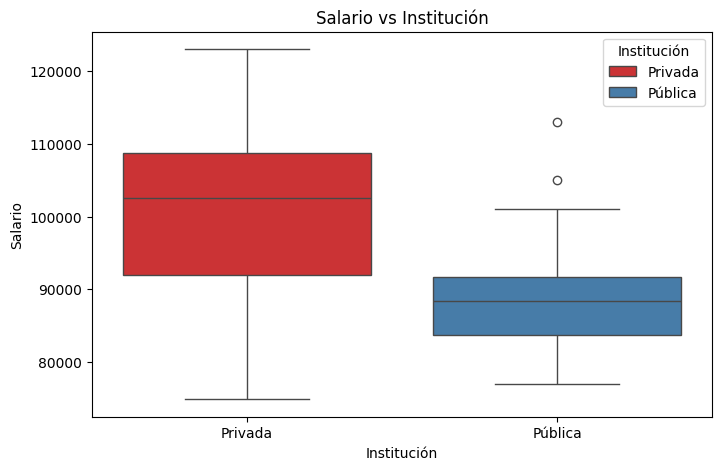

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
box = sns.boxplot(x='public_encoded', y='salary', hue='public_encoded', data=df,
                  palette='Set1')

# Modificar manualmente las etiquetas de la leyenda
handles, labels = box.get_legend_handles_labels()
nuevas_etiquetas = ['Privada', 'Pública']
plt.legend(handles, nuevas_etiquetas, title='Institución')
# Cambiar etiquetas del eje X
plt.xticks(ticks=[0, 1], labels=['Privada', 'Pública'])
plt.title('Salario vs Institución')
plt.xlabel('Institución')
plt.ylabel('Salario')
plt.show()


Podemos usar otros gráficos como stripplot o swarmplot, que muestra cada observación individual agrupada por categoría

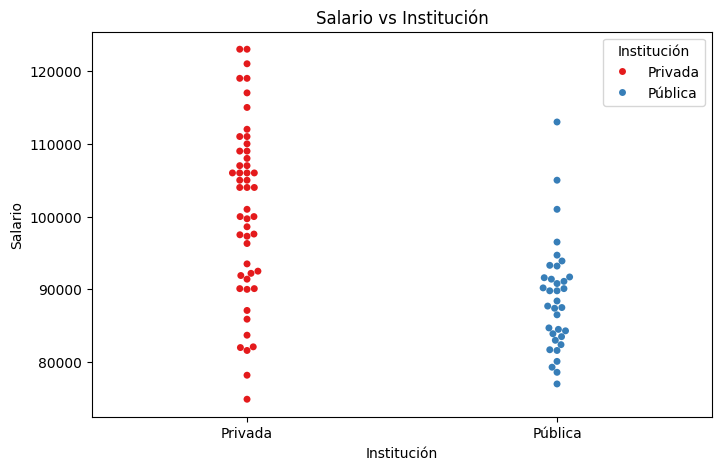

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
box = sns.swarmplot(x='public_encoded', y='salary', hue='public_encoded', data=df, palette='Set1')

# Modificar manualmente las etiquetas de la leyenda
handles, labels = box.get_legend_handles_labels()
nuevas_etiquetas = ['Privada', 'Pública']
plt.legend(handles, nuevas_etiquetas, title='Institución')
# Cambiar etiquetas del eje X
plt.xticks(ticks=[0, 1], labels=['Privada', 'Pública'])
plt.title('Salario vs Institución')
plt.xlabel('Institución')
plt.ylabel('Salario')
plt.show()

También podemos usar un diagrama de violín que añade una dimensión visual sobre cómo se distribuyen los datos. Es útil cuando hay superposición o pocos datos.


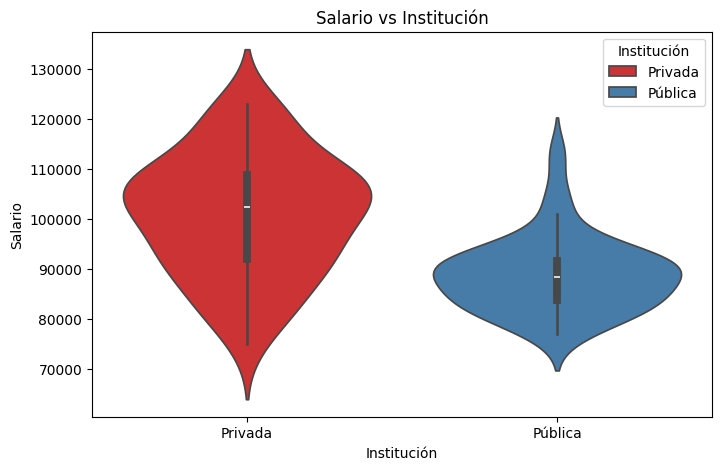

In [20]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
box = sns.violinplot(x='public_encoded', y='salary', hue='public_encoded', data=df,
                  palette='Set1')

# Modificar manualmente las etiquetas de la leyenda
handles, labels = box.get_legend_handles_labels()
nuevas_etiquetas = ['Privada', 'Pública']
plt.legend(handles, nuevas_etiquetas, title='Institución')
# Cambiar etiquetas del eje X
plt.xticks(ticks=[0, 1], labels=['Privada', 'Pública'])
plt.title('Salario vs Institución')
plt.xlabel('Institución')
plt.ylabel('Salario')
plt.show()




## Construcción del Modelo de Regresión Lineal Simple

In [21]:
from sklearn.linear_model import LinearRegression
# Variable independiente y dependiente
X = df[['public_encoded']]
y = df['salary']

# Modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Coeficientes

print("Intercepto:", modelo.intercept_)
print("Coeficiente:", modelo.coef_[0])

Intercepto: 100844.0
Coeficiente: -12009.71428571429


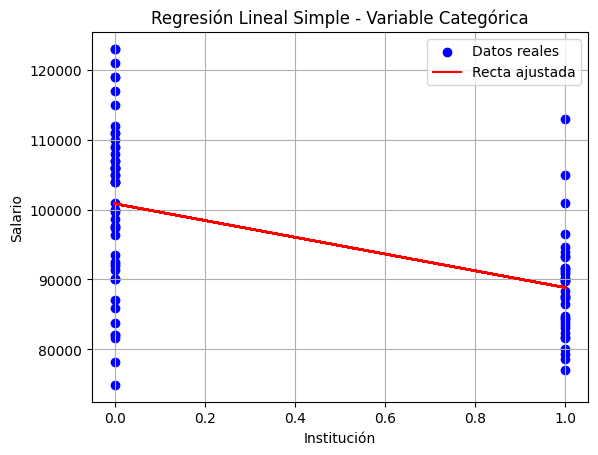

In [22]:
y_pred = modelo.predict(X)
plt.scatter(df['public_encoded'], df['salary'],color='blue', label='Datos reales')
plt.plot(df['public_encoded'], y_pred, color='red',label='Recta ajustada')
plt.title('Regresión Lineal Simple - Variable Categórica')
plt.xlabel('Institución')
plt.ylabel('Salario')
plt.legend()
plt.grid(True)
plt.show()

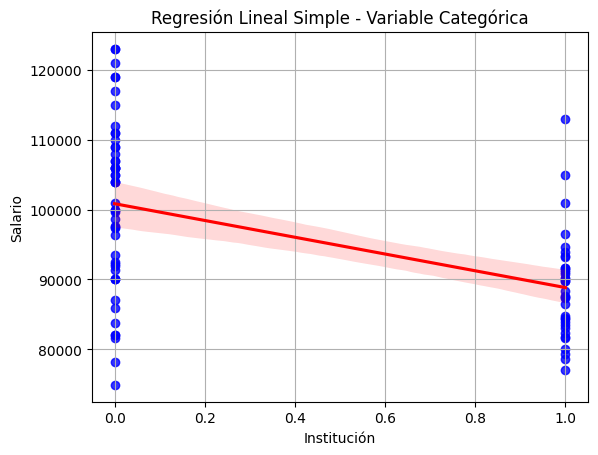

In [23]:
sns.regplot(x='public_encoded', y='salary', data=df, x_jitter=0, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Regresión Lineal Simple - Variable Categórica')
plt.xlabel('Institución')
plt.ylabel('Salario')
plt.grid(True)


## Analizar los errores residuales

Al igual que hemos visto en otras sesiones, es posible analizar el error residual

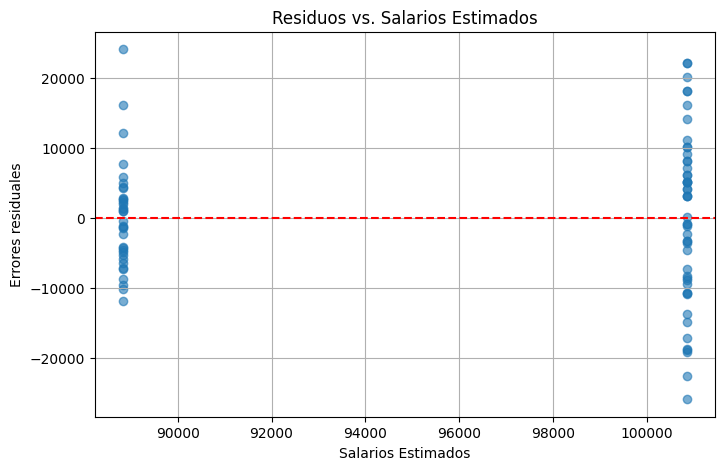

In [24]:
residuals= y-y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Salarios Estimados")
plt.ylabel("Errores residuales")
plt.title("Residuos vs. Salarios Estimados")
plt.grid(True)
plt.show()


Histograma de residuos
Muestra la distribución de los errores.

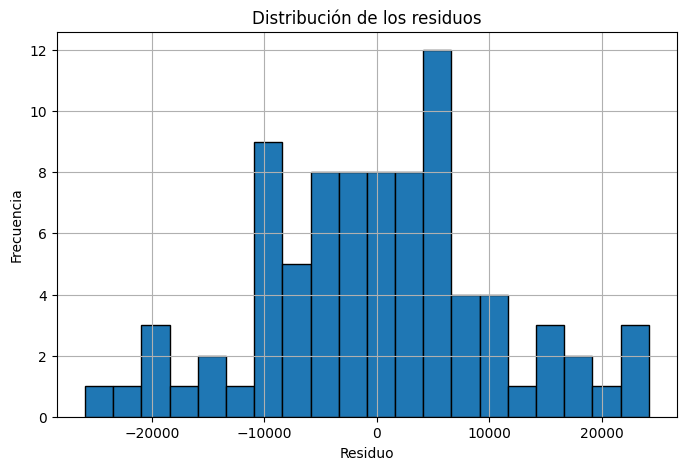

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, edgecolor='black')
plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

Q-Q Plot

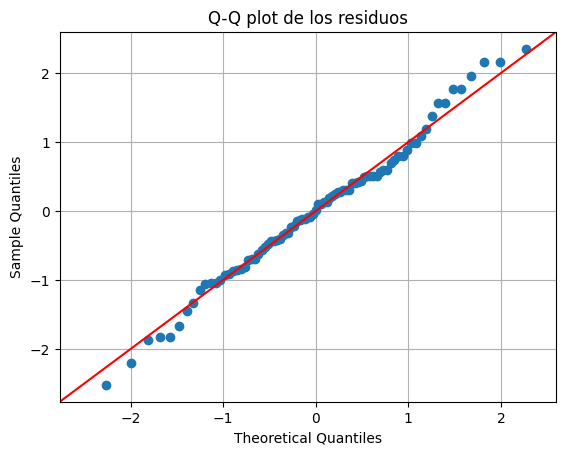

In [26]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Supón que 'residuals' contiene los residuos de tu modelo
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q plot de los residuos")
plt.grid(True)
plt.show()

# Evaluación del modelo

In [27]:
from sklearn.metrics import mean_squared_error, r2_score


mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("Error Cuadrático Medio (MSE):", mse)
print("Coeficiente de Determinación (R^2):", r2)

Error Cuadrático Medio (MSE): 105883083.02521008
Coeficiente de Determinación (R^2): 0.24808809793475628


In [28]:
import pandas as pd
import statsmodels.api as sm



X = df[['public_encoded']]
y = df['salary']

# Ajustar modelo OLS (ordinary least squares)
modelo = sm.OLS(y, X).fit()

# Resumen con p-values
print(modelo.summary())

                                 OLS Regression Results                                
Dep. Variable:                 salary   R-squared (uncentered):                   0.348
Model:                            OLS   Adj. R-squared (uncentered):              0.340
Method:                 Least Squares   F-statistic:                              44.84
Date:                Mon, 20 Oct 2025   Prob (F-statistic):                    2.28e-09
Time:                        01:23:31   Log-Likelihood:                         -1078.1
No. Observations:                  85   AIC:                                      2158.
Df Residuals:                      84   BIC:                                      2161.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

# Regresión Lineal Múltiple

Una variable independiente con 4 categorías. En este caso usaremos el mismo conjunto de datos, pero en lugar de public, emplearemos location.

In [29]:
import pandas as pd

df_multi =pd.read_csv('drive/MyDrive/Unidad03/college.csv',usecols=['salary', 'location'])

#Información general
print('Información general del conjunto de datos\n')
print(df_multi.info())


#Convertir de object a categoría
df_multi['location'] = df_multi['location'].astype('category')

print('\nInformación de la variable categórica location')
print(df_multi['location'].value_counts())

print('\nConjunto de Datos con la variable categórica codificada')
encoder = OneHotEncoder(sparse_output=False,drop='first')


encoded_data= encoder.fit_transform(df_multi[['location']])

# Crear un nuevo DataFrame con las columnas codificadas
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['location']))

# Concatenar el DataFrame codificado al DataFrame original
df_multi = pd.concat([df_multi, encoded_df], axis=1)

print(df_multi)

Información general del conjunto de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   salary    85 non-null     int64 
 1   location  85 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.5+ KB
None

Información de la variable categórica location
location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64

Conjunto de Datos con la variable categórica codificada
    salary location  location_NE  location_S  location_W
0   119000       NE          1.0         0.0         0.0
1   121000       NE          1.0         0.0         0.0
2   123000       NE          1.0         0.0         0.0
3   123000       NE          1.0         0.0         0.0
4   110000       NE          1.0         0.0         0.0
..     ...      ...          ...         ...         ...
80   79300        W          0.0         0.0         1.0
81   80100      

## Análisis Exploratorio de los Datos: Diagrama de Caja

A continuación haremos un diagrama de caja para

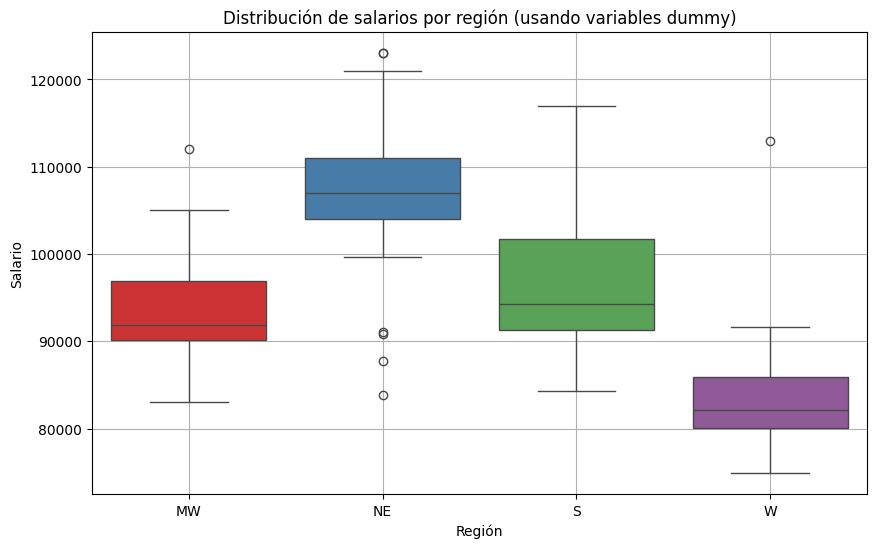

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


# Crear el boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_multi, x='location', y='salary',hue='location',
                  palette='Set1')
plt.title("Distribución de salarios por región (usando variables dummy)")
plt.xlabel("Región")
plt.ylabel("Salario")
plt.grid(True)
plt.show()

Otra versión en la que se usan los datos codificados. Observa que se tiene que crear una nueva columna, que es como reconstruir y volver al estado original

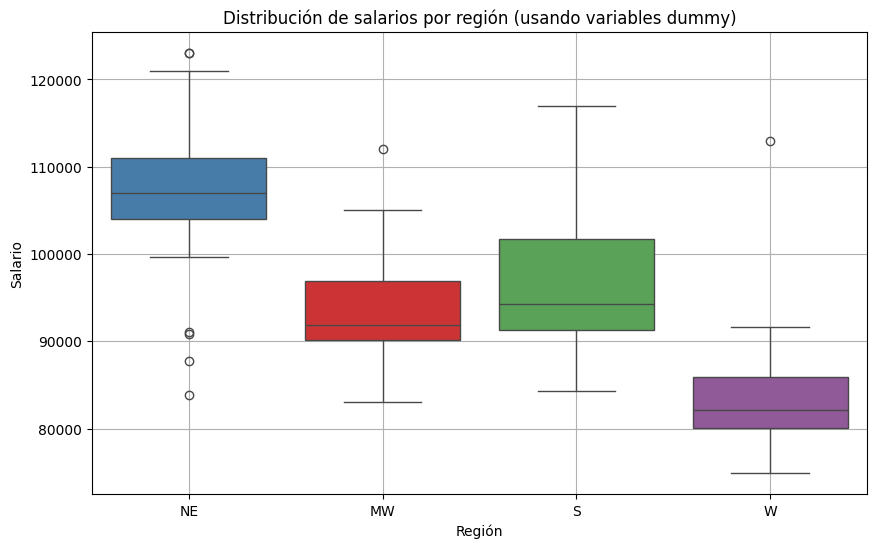

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supón que ya tienes el DataFrame 'df' con las columnas dummy:
# 'location_NE', 'location_S', 'location_W'

# Paso 1: Reconstruir la columna de región a partir de las variables dummy
def get_region(row):
    if row['location_NE'] == 1.0:
        return 'NE'
    elif row['location_S'] == 1.0:
        return 'S'
    elif row['location_W'] == 1.0:
        return 'W'
    else:
        return 'MW'  # Categoría base

df_multi['region'] = df_multi.apply(get_region, axis=1)

# Paso 2: Crear el diagrama de caja
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_multi, x='region', y='salary',hue='location',
                  palette='Set1')
plt.title("Distribución de salarios por región (usando variables dummy)")
plt.xlabel("Región")
plt.ylabel("Salario")
plt.grid(True)
plt.show()


Diagrama de Violin

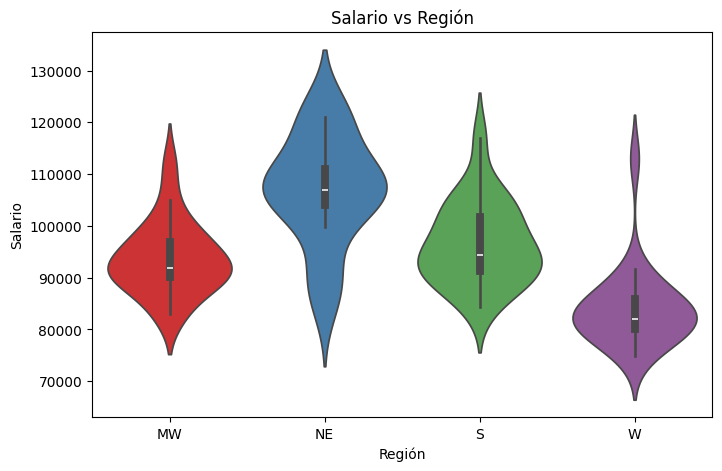

In [32]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
box = sns.violinplot(x='location', y='salary', hue='location', data=df_multi,
                  palette='Set1')

# Modificar manualmente las etiquetas de la leyenda
plt.title('Salario vs Región')
plt.xlabel('Región')
plt.ylabel('Salario')
plt.show()

## Modelo de Regresión

A continuación construiremos el modelo de regresión usando las variables dummy.

In [33]:
# Modelo de regresión lineal
X = df_multi[['location_NE', 'location_S', 'location_W']]  # MW es categoría base
y = df_multi['salary']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


# Mostrar resultados
print("Coeficientes:")
print(f"Intercepto (MW): {model.intercept_:.2f}")
print(f"location_NE: {model.coef_[0]:.2f}")
print(f"location_S : {model.coef_[1]:.2f}")
print(f"location_W : {model.coef_[2]:.2f}")

Coeficientes:
Intercepto (MW): 93694.74
location_NE: 13193.26
location_S : 2940.26
location_W : -9585.21


Al igual que en el ejercicio anterior podemos analizar los errores residuales

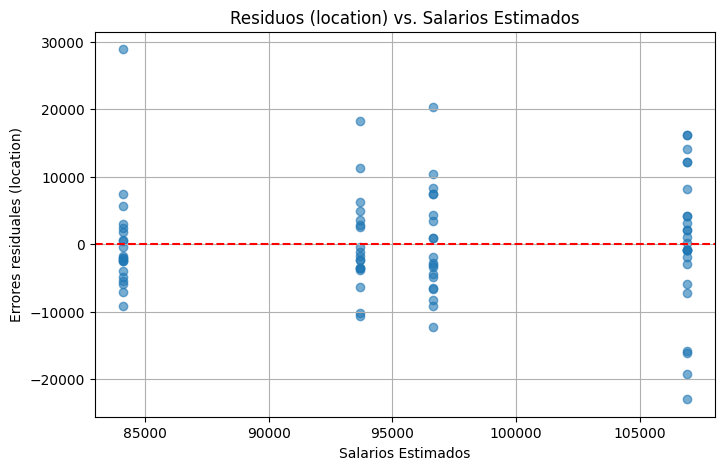

In [34]:
residuals= y-y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Salarios Estimados")
plt.ylabel("Errores residuales (location)")
plt.title("Residuos (location) vs. Salarios Estimados")
plt.grid(True)
plt.show()

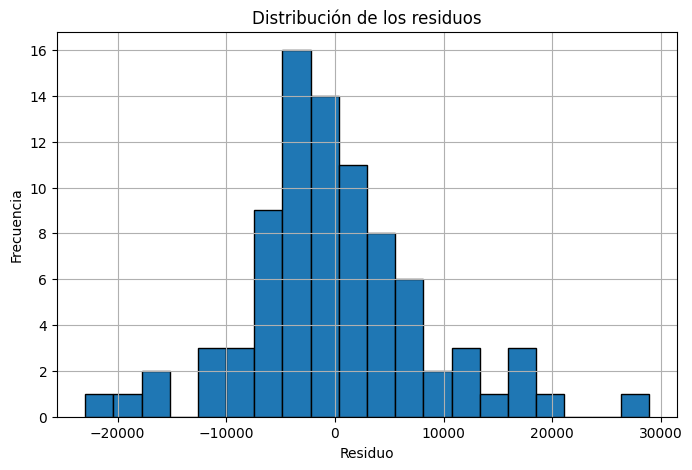

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, edgecolor='black')
plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

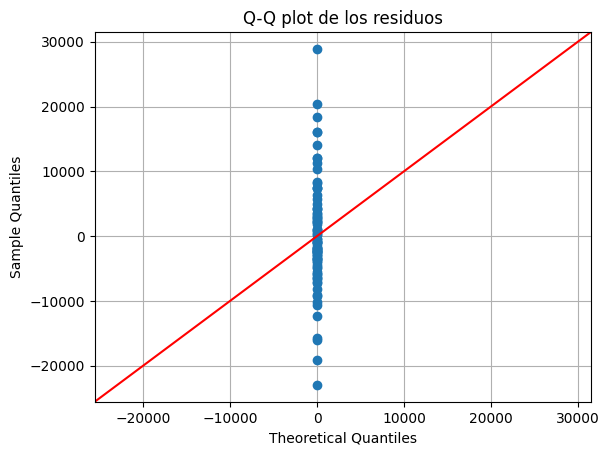

In [36]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Supón que 'residuals' contiene los residuos de tu modelo
sm.qqplot(residuals, line='45')
plt.title("Q-Q plot de los residuos")
plt.grid(True)
plt.show()

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
# Evaluación
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("\nEvaluación del modelo:")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"R² (R-squared): {r2:.4f}")


Evaluación del modelo:
Error cuadrático medio (MSE): 69748699.63
R² (R-squared): 0.5047


In [38]:
import statsmodels.formula.api as smf

model_sm = smf.ols('salary ~ C(location)', data=df_multi,drop_cols='C(location)[T.MW]').fit()
# Calcular residuos
residuals = model_sm.resid

# También puedes obtener los valores ajustados (predichos por el modelo)
fitted_values = model_sm.fittedvalues

# Opcional: agregar al DataFrame para análisis posterior
df_multi['residuals'] = residuals
df_multi['fitted'] = fitted_values

# Mostrar algunos valores
print(df_multi[['region', 'salary', 'fitted', 'residuals']].head())


  region  salary    fitted  residuals
0     NE  119000  106888.0    12112.0
1     NE  121000  106888.0    14112.0
2     NE  123000  106888.0    16112.0
3     NE  123000  106888.0    16112.0
4     NE  110000  106888.0     3112.0
